## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:/Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

In [3]:
# Create session
session = cm.Session(
    name = 'FORMAS_v2', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = '../CIBUSmod/data',
    data_path_scenarios = 'scenarios_v2',
    data_path_output = 'output',
)
# cm.ParameterRetriever.data_path_scenarios = os.path.join('scenarios')

# Define scenarios

session.add_scenario(
    name = 'baseline',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'steers',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur (incr)',
    scenario = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'steers (incr)',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur (free)',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'steers (free)',
    scenario_workbooks = ['sng_area', 'steers'],
    modules = 'all',
    pars = 'all',
    years = 0
)

TypeError: Session.add_scenario() got an unexpected keyword argument 'scenario'

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from FORMAS_multi_proc_3 import do_run

In [5]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('all')]

In [6]:
runs

[('baseline', '0'),
 ('cur', '0'),
 ('steers', '0'),
 ('cur (incr)', '0'),
 ('steers (incr)', '0'),
 ('cur (free)', '0'),
 ('steers (free)', '0')]

In [7]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=3) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cashe.clear()                  

baseline, 0 finished successfully in 3min 40s
cur, 0 finished successfully in 3min 58s
steers, 0 finished successfully in 4min 5s
cur (incr), 0 finished successfully in 3min 29s
steers (incr), 0 finished successfully in 3min 43s
cur (free), 0 finished successfully in 3min 48s
steers (free), 0 finished successfully in 2min 34s
CPU times: total: 31.2 ms
Wall time: 10min 34s


In [27]:
session.get_attr('c','area',{'crop':['land_use']}).loc[:,'cropland']/1000000

scn            year
baseline       0       2.460513
cur            0       2.341856
cur (incr)     0       2.460513
cur (free)     0       2.460513
steers (free)  0       2.460513
Name: cropland, dtype: float64

In [11]:
plot_data

,crop_group2,Cereals,Fallow,Fodder crops,Other arable,"Vegetables, berries and fruit"
scn,year,,,,,
baseline,0,0.946509,0.151051,1.146174,0.203124,0.013655
cur,0,0.947067,0.151983,1.025728,0.203272,0.013684
cur (incr),0,0.795655,0.120841,1.353072,0.180669,0.010276
cur (free),0,0.727043,0.120841,1.448321,0.153951,0.010357
steers,0,0.917764,0.151751,1.072823,0.198698,0.013671
steers (incr),0,0.748804,0.120841,1.408559,0.173195,0.009113
steers (free),0,0.670004,0.120841,1.519222,0.139988,0.010458


(<Axes: >, [<Axes: label='inset_axes'>])

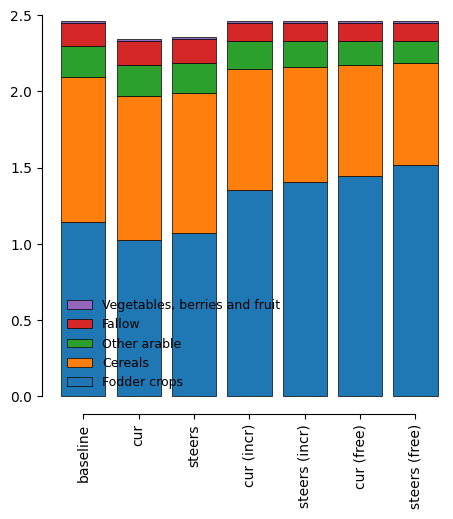

In [16]:
fig, ax = plt.subplots(figsize=(5,5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .droplevel('year')
    .loc[:,'cropland']
)/1000000
cm.plot.bar(
    plot_data,
    ax=ax,
    sort_xlabels=False,
    sort_groups=False
)

In [29]:
session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands']/1000000

scn            year
baseline       0       0.450275
cur            0       0.677365
cur (incr)     0       1.303343
cur (free)     0       2.101110
steers (free)  0       2.282689
Name: semi-natural grasslands, dtype: float64

(<Axes: >, [<Axes: label='inset_axes'>])

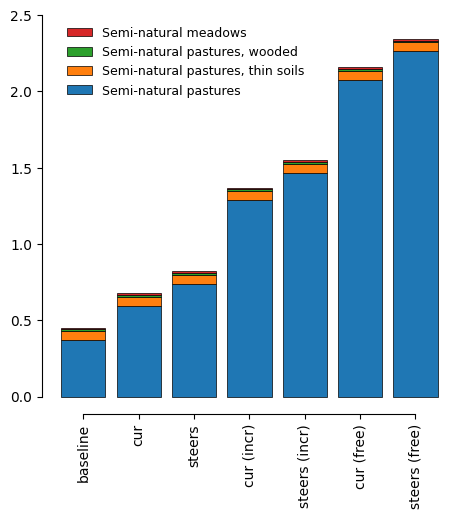

In [20]:
fig, ax = plt.subplots(figsize=(5,5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .droplevel('year')
    .loc[:,'semi-natural grasslands']
)/1000000
cm.plot.bar(
    plot_data,
    ax=ax,
    sort_xlabels=False,
    sort_groups=False
)

## Plot results

In [21]:
# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, years[-1]) for scn, years in session.scenarios('has output').items()]

### Bar plots: Production and animal heads

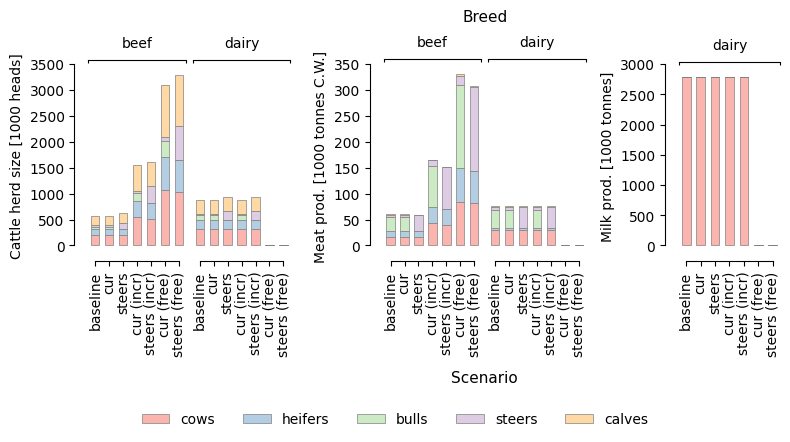

In [22]:
fig, axs = plt.subplots(1,3, figsize=(8,4), width_ratios=(1,1,0.5))

plot_data = (
    session.get_attr('A','heads',['species','animal','breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1)
    .stack().droplevel('year')
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000

ax=axs[0]
cm.plot.bar(
    plot_data,
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Cattle herd size [1000 heads]', ylabel_fontsize=10
)
ax.get_legend().remove()

plot_data = (
    session.get_attr('A','production',['species','animal','animal_prod', 'breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1).droplevel('year')
    .stack()
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000000

ax = axs[1]
cm.plot.bar(
    plot_data.xs('meat', level='animal_prod', axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    grouptitle='Breed', xlabel='Scenario', ylabel='Meat prod. [1000 tonnes C.W.]', ylabel_fontsize=10
)
ax.get_legend().remove()

ax = axs[2]
cm.plot.bar(
    plot_data.drop('beef', level='breed').xs('milk', level='animal_prod', axis=1).reindex(plot_data.columns.unique('animal'), axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Milk prod. [1000 tonnes]', ylabel_fontsize=10
)
ax.get_legend().remove()

fig.legend(*axs[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5,0), ncol=5, frameon=False)
plt.tight_layout()
plt.show()

In [23]:
plot_data = pd.concat([
    session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands'].rename('SNG')/1000000,
    cm.get_GHG(session).sum(axis=1).rename('GHG')/1000000000
], axis=1).set_index('SNG', append=True)['GHG'].unstack('scn').droplevel('year')

In [26]:
plot_data

scn,baseline,cur,cur (free),cur (incr),steers,steers (free),steers (incr)
SNG,,,,,,,
0.450275,8.782189,NaN,NaN,NaN,NaN,NaN,NaN
0.677303,NaN,8.869884,NaN,NaN,NaN,NaN,NaN
0.820416,NaN,NaN,NaN,NaN,9.238895,NaN,NaN
1.367316,NaN,NaN,NaN,11.992678,NaN,NaN,NaN
1.549205,NaN,NaN,NaN,NaN,NaN,NaN,12.389044
2.158885,NaN,NaN,13.674434,NaN,NaN,NaN,NaN
2.343701,NaN,NaN,NaN,NaN,NaN,14.186498,NaN


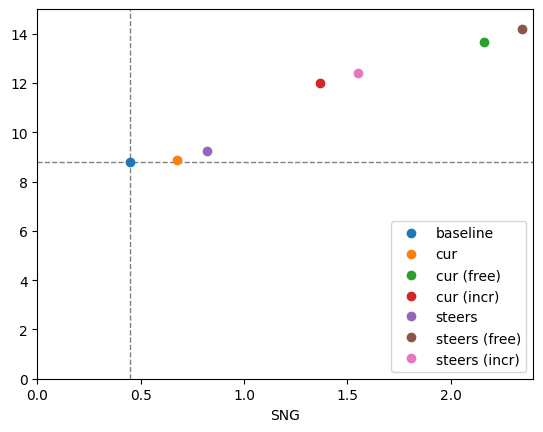

In [28]:
fig,ax = plt.subplots()
ax.axhline(y=plot_data['baseline'].dropna().values, color='grey', linestyle='--', linewidth=1)
ax.axvline(x=plot_data['baseline'].dropna().index.values, color='grey', linestyle='--', linewidth=1)

for col in plot_data.columns:
    plot_data[col].dropna().plot(linestyle='', marker='o')

ax.set_xlim([0,2.4])
ax.set_ylim([0,15])

ax.legend()
plt.show()

In [10]:
_

(<Axes: title={'center': 'sheep, none, winter lamb'}>,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

In [13]:
d

crop                                                            Ley for grazing  \
scn           year species breed                   sub_system                     
baseline      0    cattle  beef                    ley based           0.236668   
                                                   maize based         0.098336   
                           dairy                   ley based           0.169025   
                                                   maize based         0.060239   
                   horses  cold blooded horses     none                0.019661   
...                                                                         ...   
steers (free) 0    horses  trotters and racehorses none                0.018308   
                   sheep   none                    autumn lamb         0.006522   
                                                   other sheep         0.008951   
                                                   spring lamb         0.002328   
                                                   winter lamb         0.003850   

crop                                                            Semi-natural pastures  \
scn           year species breed                   sub_system                           
baseline      0    cattle  beef                    ley based                 0.189236   
                                                   maize based               0.070393   
                           dairy                   ley based                 0.109281   
                                                   maize based               0.038796   
                   horses  cold blooded horses     none                      0.011026   
...                                                                               ...   
steers (free) 0    horses  trotters and racehorses none                      0.054396   
                   sheep   none                    autumn lamb               0.026096   
                                                   other sheep               0.032901   
                                                   spring lamb               0.008607   
                                                   winter lamb               0.016346   

crop                                                            Semi-natural pastures, thin soils  \
scn           year species breed                   sub_system                                       
baseline      0    cattle  beef                    ley based                             0.002134   
                                                   maize based                           0.004678   
                           dairy                   ley based                             0.002655   
                                                   maize based                           0.006794   
                   horses  cold blooded horses     none                                  0.000234   
...                                                                                           ...   
steers (free) 0    horses  trotters and racehorses none                                  0.000468   
                   sheep   none                    autumn lamb                           0.000663   
                                                   other sheep                           0.000732   
                                                   spring lamb                           0.000269   
                                                   winter lamb                           0.000651   

crop                                                            Semi-natural pastures, wooded  
scn           year species breed                   sub_system                                  
baseline      0    cattle  beef                    ley based                         0.002804  
                                                   maize based                       0.000684  
                           dairy                   ley based    

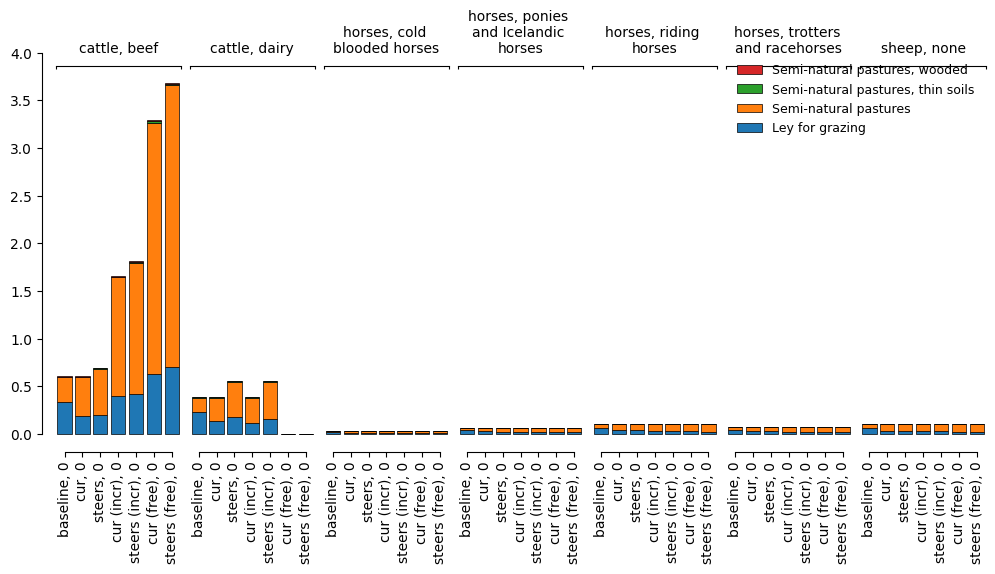

In [15]:
plot_data = (
    session.get_attr('c','production_per_use',['crop','demand'])
    .loc[:,['Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
)/1000000000
plot_data.columns = pd.MultiIndex.from_tuples(
    [(cr,) + tuple(an.replace('feed (','').replace(')','').split(', ')) for cr, an in plot_data.columns],
    names = ['crop', 'species', 'breed', 'sub_system']
)
plot_data = (
    plot_data.T.groupby(['species','breed','crop']).sum().T
    .stack(['species','breed'])
)
# for sp,br,ss in plot_data.index.droplevel(['scn','year']).unique():
fig,ax = plt.subplots(figsize=(12,5))
d = plot_data#.xs((sp,br,ss), level=('species','breed','sub_system')).dropna(axis=1)
cm.plot.bar(
    d,
    ax=ax,
    group_levels=['species','breed'],
    sort_groups=False,
    sort_xlabels=False,
    sort_categories=False
)
# ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
plt.show()

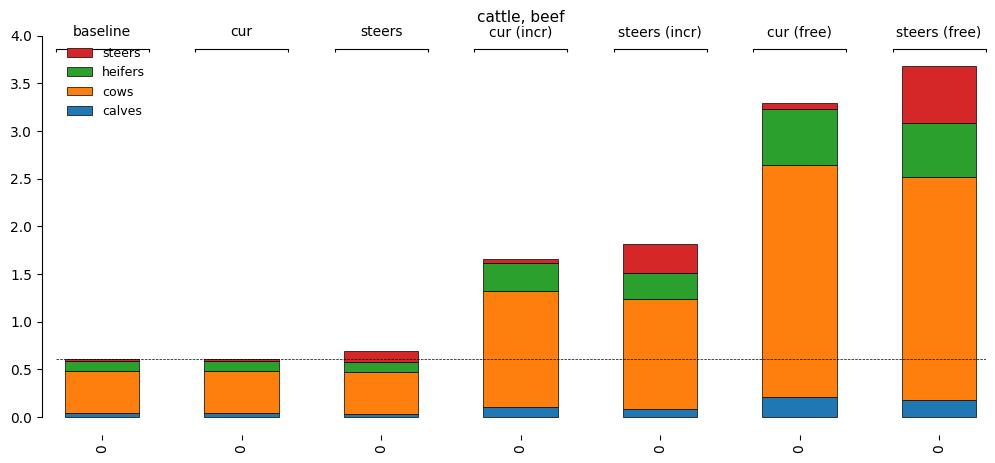

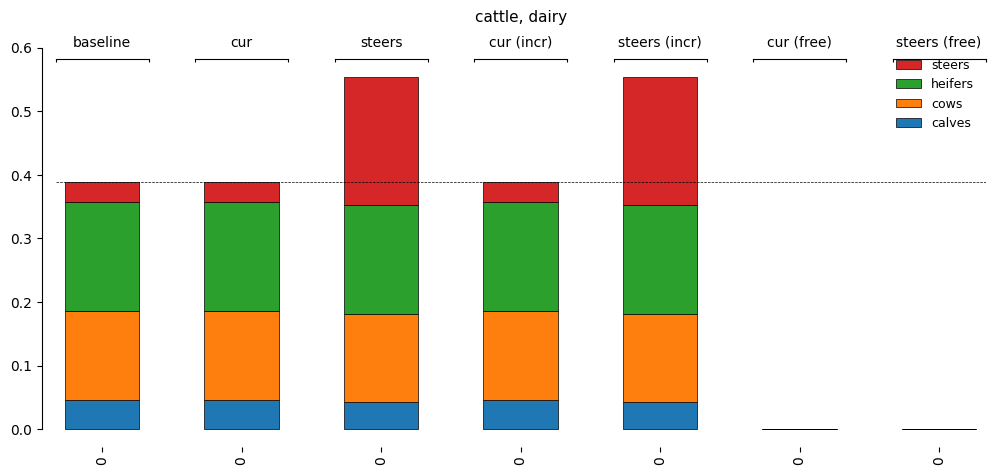

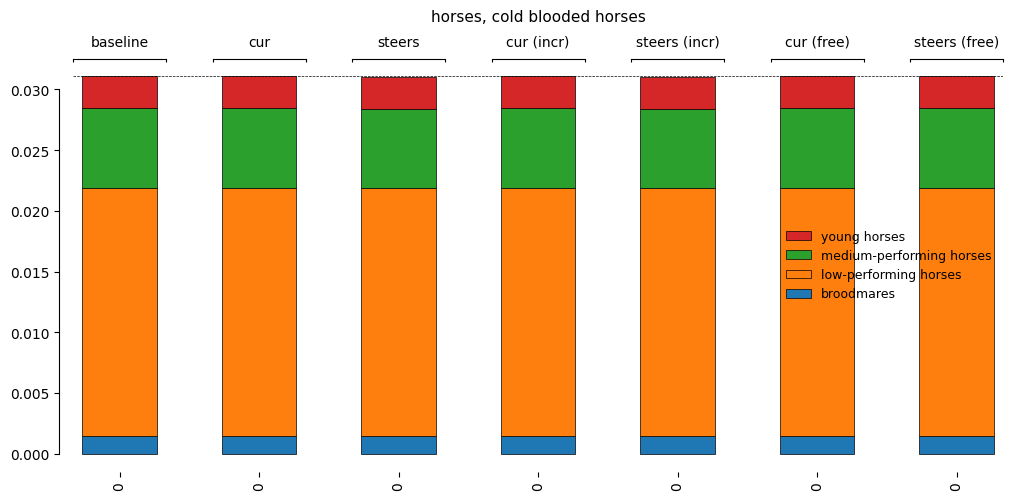

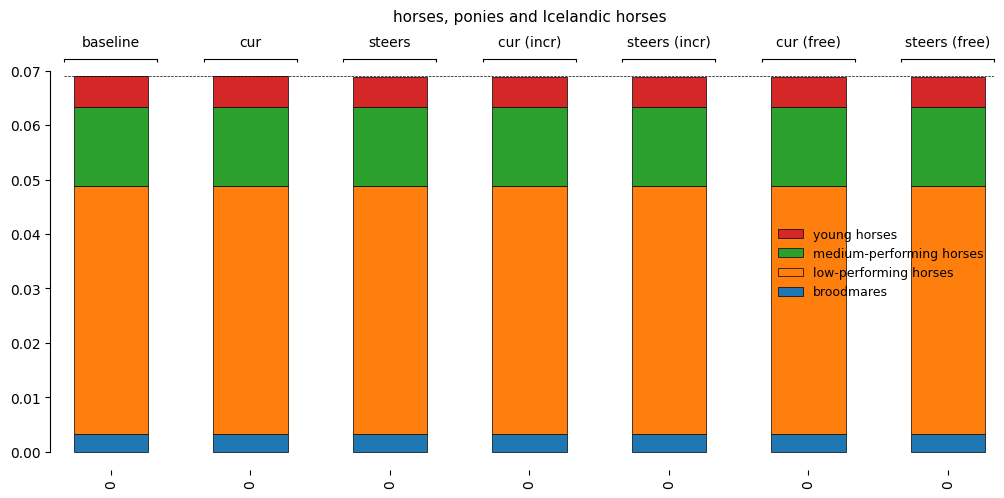

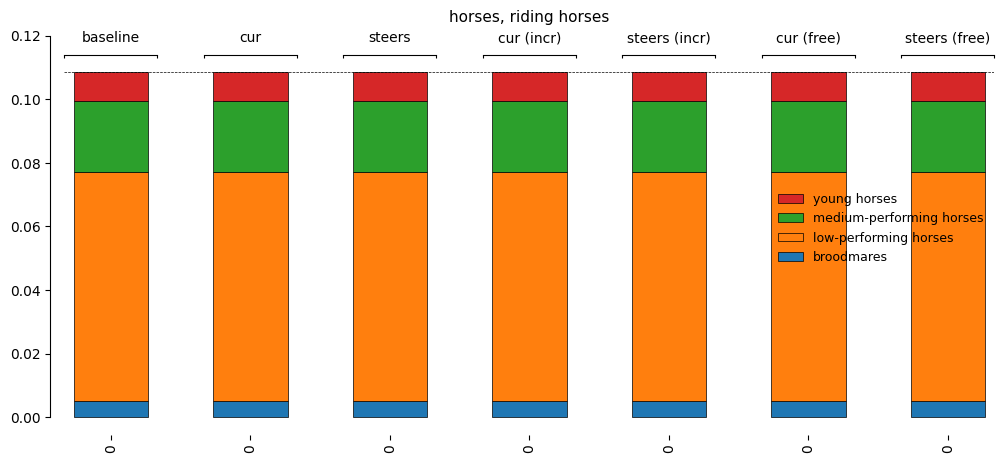

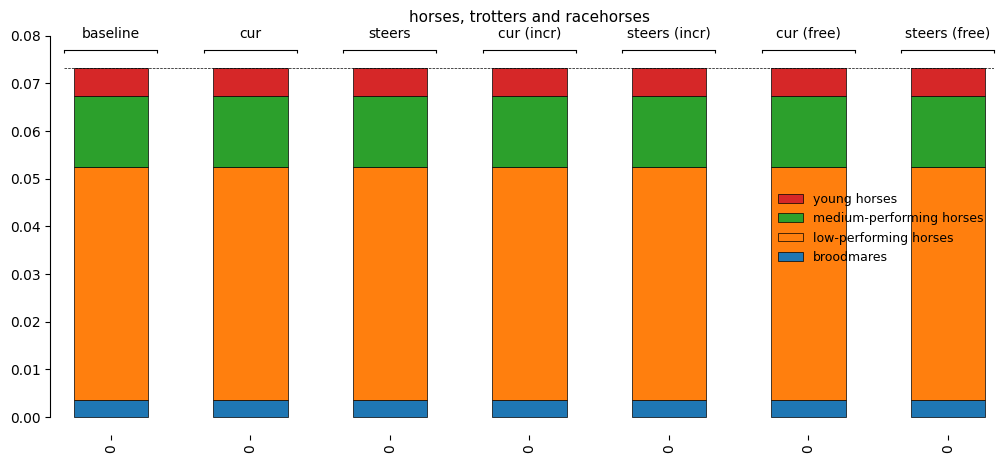

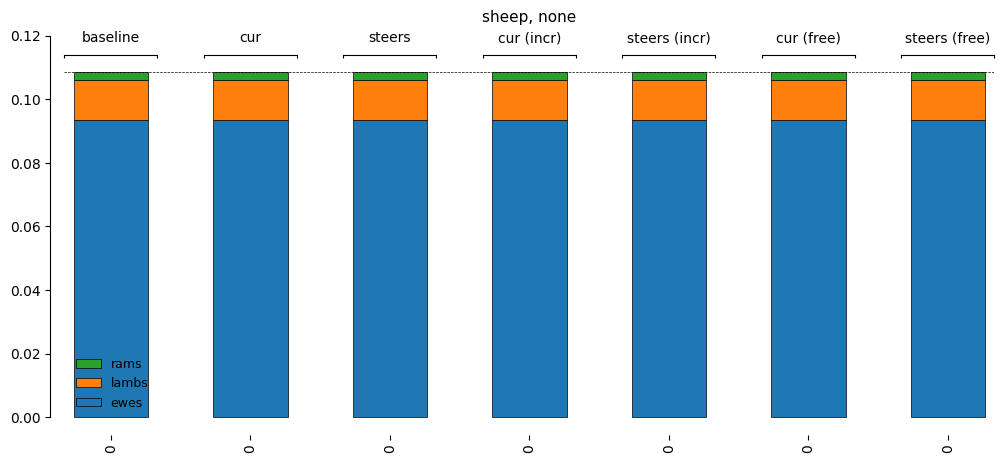

In [4]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .loc[:,'domestic']
    .loc[:,'grazing']
    .stack(['species','breed'])
)/1000000000
for sp,br in plot_data.index.droplevel(['scn','year']).unique():
    fig,ax = plt.subplots(figsize=(12,5))
    d = plot_data.xs((sp,br), level=('species','breed')).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['scn'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=f"{sp}, {br}"
    )
    ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    plt.show()

In [ ]:
session.get_attr('C','production_per','species')

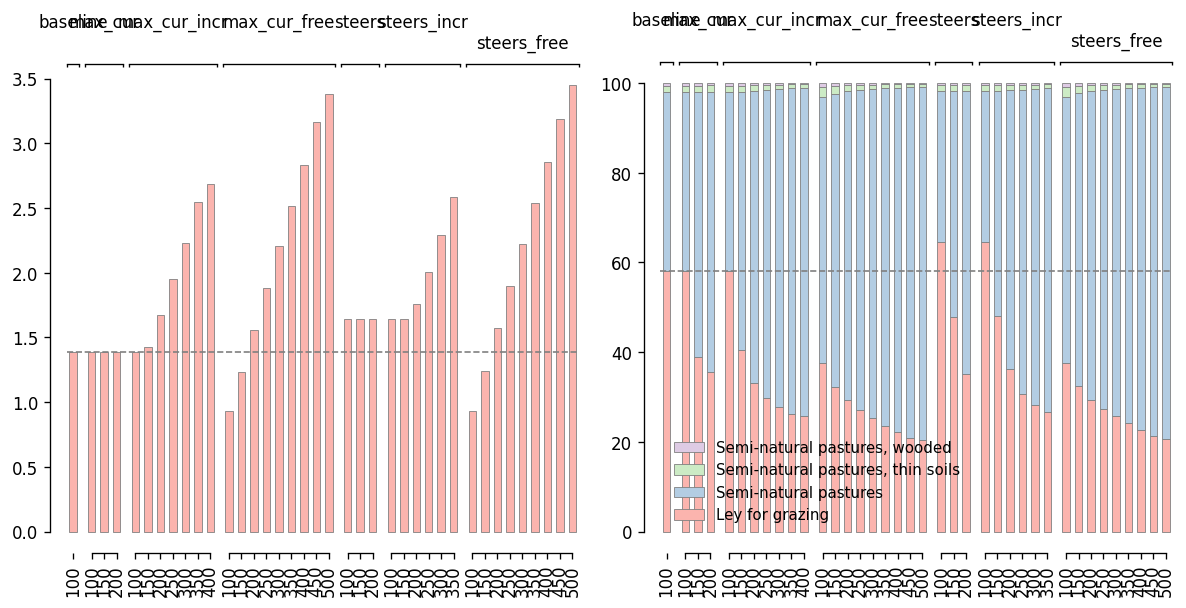

scn           year
baseline      100     41.906850
max_cur       100     41.906864
              150     61.083580
              200     64.415998
max_cur_incr  100     41.901215
              150     59.562779
              200     66.813800
              250     70.304686
              300     72.135064
              350     73.759035
              400     74.331333
max_cur_free  100     62.482051
              150     67.686280
              200     70.756563
              250     72.828108
              300     74.590268
              350     76.360777
              400     77.913322
              450     79.175836
              500     79.541410
steers        100     35.376497
              150     52.066116
              200     64.870948
steers_incr   100     35.376191
              150     52.051206
              200     63.859371
              250     69.350106
              300     71.880611
              350     73.381828
steers_free   100     62.425542
              150    

In [29]:
grazing = session.get_attr('C', 'production', ['crop_prod','crop']).loc[:,'grazing']
grazing = grazing.loc[:,grazing.sum()!=0]

plot_data1 = (
    grazing
    # .loc[SCN_NAME]
    # .rename(scn_name_map)
    /1000000000
)

plot_data2 = plot_data1.apply(lambda x: x/x.sum()*100, axis=1)

fig,axs = plt.subplots(1,2, figsize=(10,5), dpi=120)
ax=axs[0]
cm.plot.bar(plot_data1.sum(axis=1), group_levels='scn', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False)
ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'].iloc[0], linestyle='--', linewidth=1, color='grey')
# ax.set_ylabel('Total grazing [Mt DM]')
# ax.set_xlabel('')

ax = axs[1]
cm.plot.bar(plot_data2, group_levels='scn', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False, sort_categories=False)
ax.axhline(y=plot_data2.loc['baseline','Ley for grazing'].iloc[0], linestyle='--', linewidth=1, color='grey')
# ax.legend(loc='lower left', ncol=1, bbox_to_anchor=(1, 0), fontsize=10)
# ax.set_ylabel('Share of grazing from\ndifferent pastures [%]')
# ax.set_xlabel('')

plt.tight_layout()
plt.show()

100-plot_data2.loc[:,'Ley for grazing']

In [14]:
 session.get_attr('geo','x_crops', scn='baseline').iloc[0].loc[['Semi-natural pastures']].sum()/1000*3

1105.9310944650654

In [29]:
import os
a=os.path.join('hej','hej')
type(a)

str

In [43]:
for x,y in enumerate(plot_data.sum(axis=1)):
    print(x)
    print(str(round(y,2)))

0
0.8
1
0.8
2
0.82
3
0.9


In [34]:
list(range(len(plot_data)))

[0, 1, 2, 3]

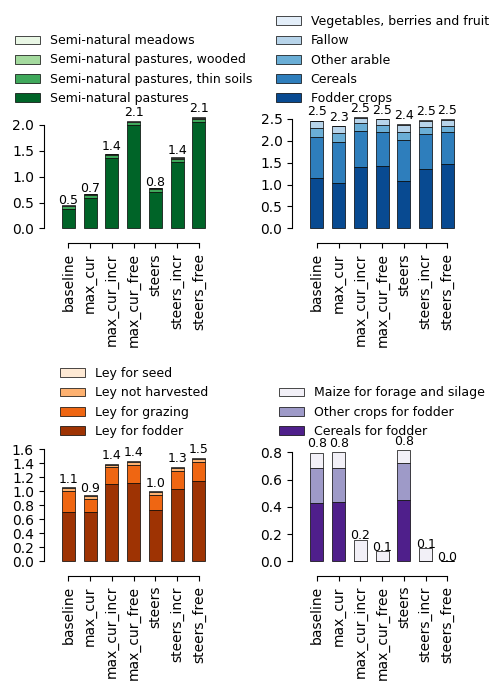

In [16]:
fig, axs = plt.subplots(2,2, figsize=(5,7), width_ratios=(1,1))
axs = axs.flatten()

ax = axs[0]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'semi-natural grasslands']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Greens')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[1]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'cropland']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Blues')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[2]
plot_data = (
    session.get_attr('c','area',{'crop':['crop_group',None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,'Ley']
)/1000000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Oranges')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

ax=axs[3]
plot_data = (
    session.get_attr('c','area',{'crop':[None]})
    .loc[scn_final,:]
    .droplevel('year')
    .loc[:,['Maize for forage and silage', 'Cereals for fodder', 'Other crops for fodder']]
)/100000
cm.plot.bar(plot_data, ax=ax, bar_width=0.6, sort_xlabels=False, cmap='Purples')
for x,y in enumerate(plot_data.sum(axis=1)):
    ax.text(x=x+0.5, y=y*1.05, s=str(round(y,1)), ha='center', size=9)

for ax in axs.flatten():
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1), frameon=False, ncol=1, fontsize=9, reverse=True)

plt.tight_layout()
plt.show()

[0, 1, 2, 3]

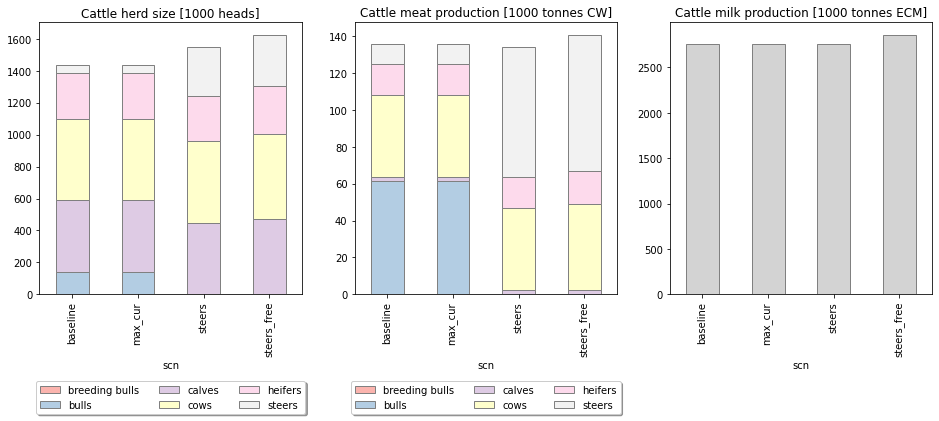

In [55]:
fig, axs = plt.subplots(1,3, figsize=(16,5))

plot_data = pd.concat(
    [pd.concat([
        output.loc[(scn,year),'ani']
        .heads.sum()
        .groupby(['species','animal'])
        .sum()
    ],keys=[scn],names=['scn'])
     for scn in scenarios]
)/1000

ax=axs[0]
ax.set_title('Cattle herd size [1000 heads]')
(
    plot_data
    .xs(('cattle'),level=('species'))
    .unstack()
    .plot.bar(stacked=True, ax=ax, **bar_style)
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),
          ncol=3, fancybox=True, shadow=True)

plot_data = pd.concat(
    [pd.concat([
        output.loc[(scn,year),'ani']
        .production.sum()
        .groupby(['species','animal','animal_prod'])
        .sum()
    ],keys=[scn],names=['scn'])
     for scn in scenarios]
)/1000000

ax = axs[1]
ax.set_title('Cattle meat production [1000 tonnes CW]')
(
    plot_data
    .xs(('cattle','meat'),level=('species','animal_prod'))
    .unstack()
    .plot.bar(stacked=True, ax=ax, **bar_style)
)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),
          ncol=3, fancybox=True, shadow=True)

ax = axs[2]
ax.set_title('Cattle milk production [1000 tonnes ECM]')
(
    plot_data
    .xs(('cattle','milk','cows'),level=('species','animal_prod','animal'))
    .plot.bar(stacked=True, ax=ax, **bar_style_one)
)

plt.show()

### Bar plots: GHG and land use

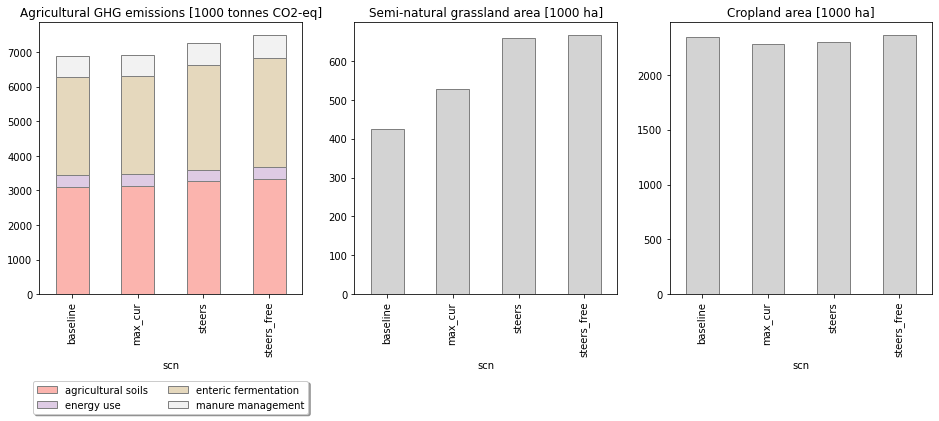

In [65]:
fig, axs = plt.subplots(1,3, figsize=(16,5)) # , gridspec_kw={'width_ratios': [1, 2]})
rel = cm.ParameterRetriever.get_rel('crop','land_use')

plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['scn','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[0]
plot_data.plot.bar(stacked=True, ax = ax, **bar_style)
ax.set_title('Agricultural GHG emissions [1000 tonnes CO2-eq]')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),
          ncol=2, fancybox=True, shadow=True)

plot_data = pd.concat(
    [pd.concat([output.loc[(scn,year),'crp'].area.rename(rel).groupby('crop').sum()],keys=[scn],names=['scn'])
     for scn in scenarios]
)/1000

ax = axs[1]
plot_data.xs('semi-natural grasslands',level='crop').plot.bar(ax = ax, **bar_style_one)
ax.set_title('Semi-natural grassland area [1000 ha]')

ax = axs[2]
plot_data.xs('cropland',level='crop').plot.bar(ax = ax, **bar_style_one)
ax.set_title('Cropland area [1000 ha]')

plt.show()

### Maps: Land use and cattle numbers

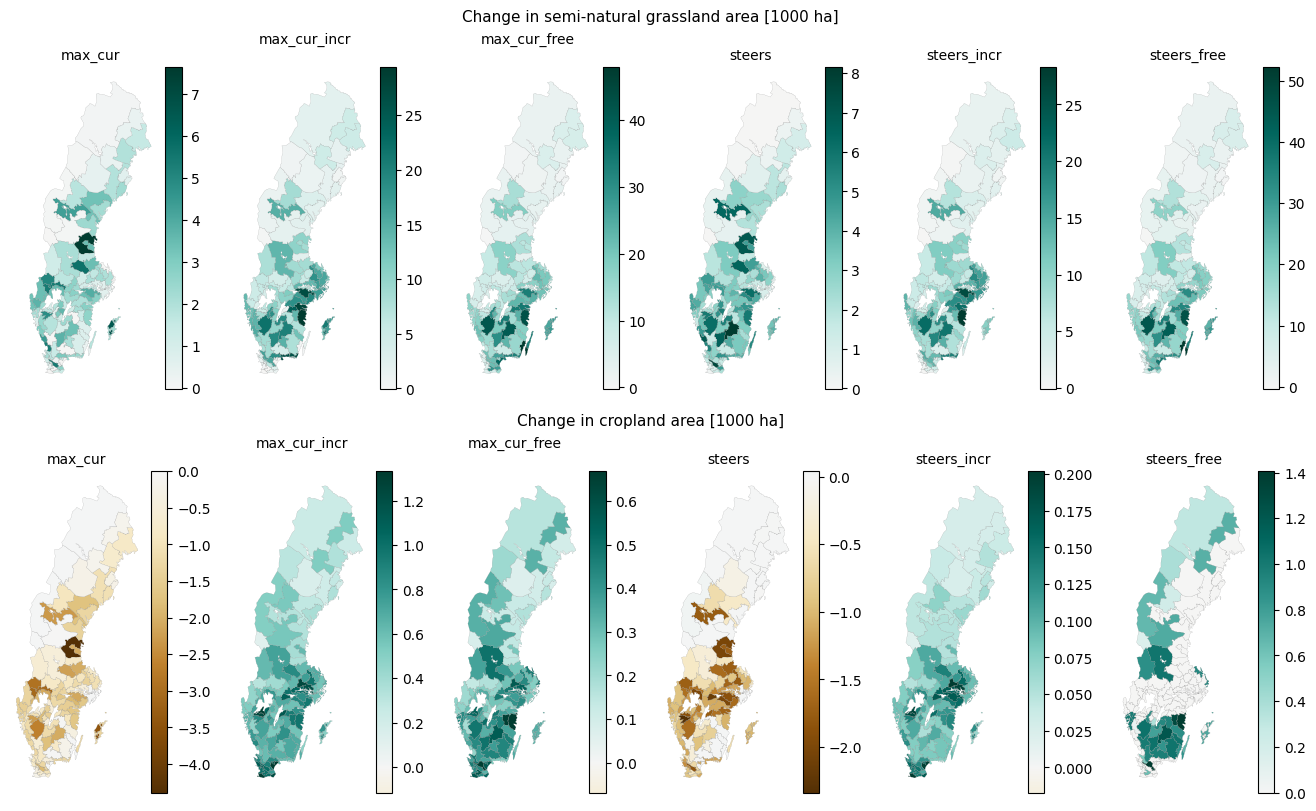

In [17]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('baseline','100')],axis=1))
    .drop(('baseline','100'))
    .droplevel('year')
)/1000


n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

# fig,axs = plot.subplots(plot_data.T.drop('greenhouse'),
#                         size=(2.5,4), columns='scn', index='land_use', title_fontsize=11,
#                         plot_fn=plot.map_from_series,
#                         cmap_zero_midpoint=False, **map_style_div, vmax=8, vmin=-8)
# for ax in axs.flatten():
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

fig = plt.figure(layout='constrained', figsize=(2.2*n_scn, 8))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        # vmin=-lims.loc['semi-natural grasslands'],
        cmap_zero_midpoint='shrink',
        # vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        # vmin=-lims.loc['cropland'],
        cmap_zero_midpoint='shrink',
        # vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)
# fig.tight_layout()
plt.show()

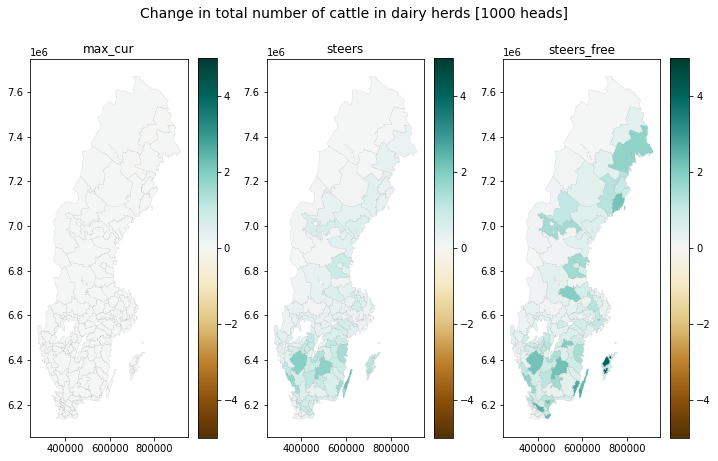

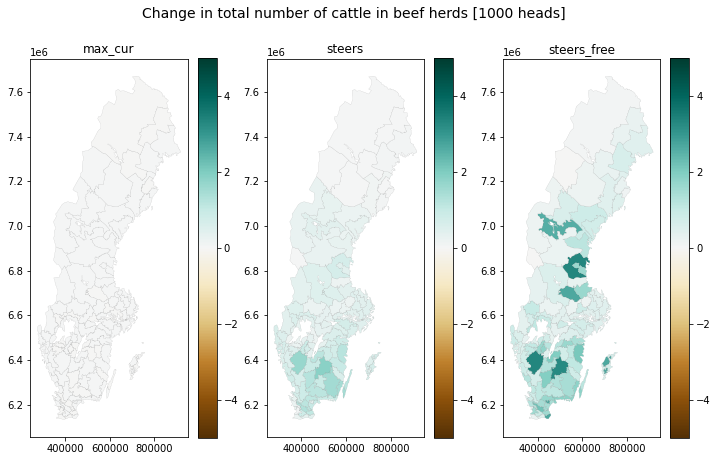

In [22]:
n_scn = len(scenarios)-1
fig, axs = plt.subplots(1,n_scn, figsize=(4*n_scn,7))
n=0
for scn in list(scenarios.keys())[1:]:
    plot_data = (
        output.loc[(scn,year),'ani'].heads.xs(('cattle','dairy'), axis=1).sum(axis=1) -
        output.loc[('baseline',year),'ani'].heads.xs(('cattle','dairy'), axis=1).sum(axis=1)
    )/1000
    ax = axs[n]
    plot.map_from_series(
        plot_data,
        ax = ax,
        vmin=-5,
        vmax=5,
        **map_style_div
    )
    ax.set_title(scn)
    n += 1
plt.suptitle('Change in total number of cattle in dairy herds [1000 heads]', size=14)
plt.show()

fig, axs = plt.subplots(1,n_scn, figsize=(4*n_scn,7))
n=0
for scn in list(scenarios.keys())[1:]:
    plot_data = (
        output.loc[(scn,year),'ani'].heads.xs(('cattle','beef'), axis=1).sum(axis=1) -
        output.loc[('baseline',year),'ani'].heads.xs(('cattle','beef'), axis=1).sum(axis=1)
    )/1000
    ax = axs[n]
    plot.map_from_series(
        plot_data,
        ax = ax,
        vmin=-5,
        vmax=5,
        **map_style_div
    )
    ax.set_title(scn)
    n += 1
plt.suptitle('Change in total number of cattle in beef herds [1000 heads]', size=14)
plt.show()



### Feed rations

In [57]:
feed_rations = (
    (
        output.loc[('baseline',year),'ani'].feed.consumption.sum().groupby(['species','breed','animal','feed']).sum() /
        output.loc[('baseline',year),'ani'].heads.sum().groupby(['species','breed','animal']).sum()
    )
    .unstack(['species','breed','animal'])
    .loc[:,'cattle']
    .dropna(how='all')
    .dropna(how='all', axis=1)
)

feed_rations.to_clipboard()
feed_rations

breed                               beef                           \
animal                             bulls      calves         cows   
feed                                                                
barley                        732.466575    0.000000     0.000000   
broad beans                    60.671369    0.000000     0.000000   
grazing                         0.000000  441.759559  2001.138084   
ley silage, 1st cut          2722.415598    0.000000     0.000000   
ley silage, regrowth            0.000000  999.717284   676.978922   
luzern meal                     0.310046    0.000000     0.000000   
maize                           1.036433    0.000000     0.000000   
maize silage                  147.378130    0.000000     0.000000   
minerals                        5.307731    0.000000     0.000000   
oats                          151.370789    0.000000     0.000000   
other silage                    0.000000    0.000000   700.531662   
palm kernel expeller            3.981597    0.000000     0.000000   
peas                           62.862692    0.000000     0.000000   
potatoe protein                 0.034450    0.000000     0.000000   
rapeseed                       17.445274    0.000000     0.000000   
rapeseed meal                  13.881758    0.000000     0.000000   
rye                             0.000000    0.000000     0.000000   
soybean meal                    5.115897    0.000000     0.000000   
soybeans                        2.013668    0.000000     0.000000   
straw                           0.000000    0.000000   700.531662   
sugar beet molasses             2.884709    0.000000     0.000000   
sugar beet pulp                 5.192475    0.000000     0.000000   
sunflower seed meal             0.499998    0.000000     0.000000   
triticale                     277.949303    0.000000     0.000000   
vegetable oils                  2.850956    0.000000     0.000000   
wheat                         362.280964    0.000000     0.000000   
wheat bran                     11.685997    0.000000     0.000000   
wheat distillers grain, dry     4.905483    0.000000     0.000000   

breed                                                        dairy  \
animal                           heifers       steers        bulls   
feed                                                                 
barley                          0.000000     0.000000   425.235617   
broad beans                     0.000000     0.000000    33.656268   
grazing                       895.345250   914.838488     0.000000   
ley silage, 1st cut             0.000000     0.000000  1924.021225   
ley silage, regrowth         2026.197517  2070.311393     0.000000   
luzern meal                     0.000000     0.000000     0.268115   
maize                           0.000000     0.000000     0.896264   
maize silage                    0.000000     0.000000   123.104324   
minerals                        0.000000     0.000000     4.589906   
oats                            0.000000     0.000000    87.878755   
other silage                    0.000000     0.000000     0.000000   
palm kernel expeller            0.000000     0.000000     3.443121   
peas                            0.000000     0.000000    34.544973   
potatoe protein                 0.000000     0.000000     0.029791   
rapeseed                        0.000000     0.000000    15.085951   
rapeseed meal                   0.000000     0.000000    12.004370   
rye                             0.000000     0.000000     0.000000   
soybean meal                    0.000000     0.000000     4.424016   
soybeans                        0.000000     0.000000     1.741337   
straw                           0.000000     0.000000     0.000000   
sugar beet molasses             0.000000     0.000000     2.494577   
sugar beet pulp                 0.000000     0.000000     4.490238   
sunflower seed meal             0.000000     0.000000     0.432377   
triticale                       0.000000